In [179]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

In [180]:
nasa = pd.read_csv("/Users/jxu/Desktop/mids-datasci200-summer23-ZiJing-Xu/neo_updated.csv")

In [181]:
nasa.head()

,des,orbit_id,jd,cd,dist,dist_min,dist_max,v_rel,v_inf,t_sigma_f,h,diameter,diameter_sigma,fullname
0,509352,57,2.415024e+06,1900-Jan-04 22:25,0.009632,0.009625,0.009639,8.686711,8.654807,00:02,20.16,NaN,NaN,509352 (2007 AG)
1,2014 SC324,56,2.415031e+06,1900-Jan-11 01:07,0.039965,0.039906,0.040025,10.652428,10.646168,00:18,24.39,NaN,NaN,(2014 SC324)
2,2012 UK171,51,2.415032e+06,1900-Jan-12 23:07,0.049822,0.049496,0.050147,7.157357,7.149881,00:13,24.43,NaN,NaN,(2012 UK171)
3,4660,267,2.415049e+06,1900-Jan-29 18:10,0.020798,0.020767,0.020829,5.544877,5.521724,00:35,18.75,0.33,0.05,4660 Nereus (1982 DB)
4,2015 RW83,8,2.415055e+06,1900-Feb-04 03:50,0.033117,0.032581,0.060207,3.144019,3.118323,14:49,24.10,NaN,NaN,(2015 RW83)


In [182]:
nasa['date'] = nasa['cd'].str[:11]
nasa['time'] = nasa['cd'].str[12:17]

In [183]:
nasa.head()

,des,orbit_id,jd,cd,dist,dist_min,dist_max,v_rel,v_inf,t_sigma_f,h,diameter,diameter_sigma,fullname,date,time
0,509352,57,2.415024e+06,1900-Jan-04 22:25,0.009632,0.009625,0.009639,8.686711,8.654807,00:02,20.16,NaN,NaN,509352 (2007 AG),1900-Jan-04,22:25
1,2014 SC324,56,2.415031e+06,1900-Jan-11 01:07,0.039965,0.039906,0.040025,10.652428,10.646168,00:18,24.39,NaN,NaN,(2014 SC324),1900-Jan-11,01:07
2,2012 UK171,51,2.415032e+06,1900-Jan-12 23:07,0.049822,0.049496,0.050147,7.157357,7.149881,00:13,24.43,NaN,NaN,(2012 UK171),1900-Jan-12,23:07
3,4660,267,2.415049e+06,1900-Jan-29 18:10,0.020798,0.020767,0.020829,5.544877,5.521724,00:35,18.75,0.33,0.05,4660 Nereus (1982 DB),1900-Jan-29,18:10
4,2015 RW83,8,2.415055e+06,1900-Feb-04 03:50,0.033117,0.032581,0.060207,3.144019,3.118323,14:49,24.10,NaN,NaN,(2015 RW83),1900-Feb-04,03:50


In [184]:
nasa = nasa.astype({"time":'datetime64[ns]'})

In [185]:
nasa['time'] = pd.to_datetime(nasa['time'], format='%H:%M').dt.time
nasa['time'] = nasa['time'].apply(lambda x: str(x)[:-3])

In [187]:
nasa['date'] = pd.to_datetime(nasa['date'])
nasa.head()

,des,orbit_id,jd,cd,dist,dist_min,dist_max,v_rel,v_inf,t_sigma_f,h,diameter,diameter_sigma,fullname,date,time
0,509352,57,2.415024e+06,1900-Jan-04 22:25,0.009632,0.009625,0.009639,8.686711,8.654807,00:02,20.16,NaN,NaN,509352 (2007 AG),1900-01-04,22:25
1,2014 SC324,56,2.415031e+06,1900-Jan-11 01:07,0.039965,0.039906,0.040025,10.652428,10.646168,00:18,24.39,NaN,NaN,(2014 SC324),1900-01-11,01:07
2,2012 UK171,51,2.415032e+06,1900-Jan-12 23:07,0.049822,0.049496,0.050147,7.157357,7.149881,00:13,24.43,NaN,NaN,(2012 UK171),1900-01-12,23:07
3,4660,267,2.415049e+06,1900-Jan-29 18:10,0.020798,0.020767,0.020829,5.544877,5.521724,00:35,18.75,0.33,0.05,4660 Nereus (1982 DB),1900-01-29,18:10
4,2015 RW83,8,2.415055e+06,1900-Feb-04 03:50,0.033117,0.032581,0.060207,3.144019,3.118323,14:49,24.10,NaN,NaN,(2015 RW83),1900-02-04,03:50


In [188]:
del nasa['cd']
del nasa['jd']
del nasa['t_sigma_f']
del nasa['diameter_sigma']
nasa.rename(columns = {'des':'object', 'dis':'avg_dist','v_rel':'relative_vel', 'v_inf':'infinity_vel', 'h':'abs_magnitude'}, inplace = True)

In [189]:
nasa.head(10)

,object,orbit_id,dist,dist_min,dist_max,relative_vel,infinity_vel,abs_magnitude,diameter,fullname,date,time
0,509352,57,0.009632,0.009625,0.009639,8.686711,8.654807,20.16,NaN,509352 (2007 AG),1900-01-04,22:25
1,2014 SC324,56,0.039965,0.039906,0.040025,10.652428,10.646168,24.39,NaN,(2014 SC324),1900-01-11,01:07
2,2012 UK171,51,0.049822,0.049496,0.050147,7.157357,7.149881,24.43,NaN,(2012 UK171),1900-01-12,23:07
3,4660,267,0.020798,0.020767,0.020829,5.544877,5.521724,18.75,0.33,4660 Nereus (1982 DB),1900-01-29,18:10
4,2015 RW83,8,0.033117,0.032581,0.060207,3.144019,3.118323,24.10,NaN,(2015 RW83),1900-02-04,03:50
5,2009 BW2,17,0.016457,0.016445,0.092722,4.442861,4.406267,25.10,NaN,(2009 BW2),1900-02-04,06:16
6,2002 LY1,52,0.049041,0.049030,0.049052,10.973307,10.968355,22.30,NaN,(2002 LY1),1900-02-05,22:08
7,348306,69,0.034092,0.034091,0.034093,17.359868,17.355366,21.55,NaN,348306 (2005 AY28),1900-02-05,23:42
8,378160,73,0.036879,0.036805,0.036954,10.359253,10.352276,19.68,NaN,378160 (2006 WX1),1900-02-10,05:07
9,2020 DK,8,0.021322,0.007381,0.057971,9.904785,9.892161,26.06,NaN,(2020 DK),1900-02-10,17:56


In [190]:
print("The size of the dataset is:", len(nasa.index))
print("The number of null values for diameter is:", nasa['diameter'].isna().sum())

print("Proportion of missing data for diameter:", nasa['diameter'].isna().sum()/len(nasa.index))

The size of the dataset is: 23616
The number of null values for diameter is: 22951
Proportion of missing data for diameter: 0.9718411246612466


In [191]:
nasa.rename(columns = {'dist':'dist_avg_au', 'relative_vel':'relative_vel_kms', 'abs_magnitude':'abs_magnitude_h', 'Date':'date', 'Time':'time'}, inplace = True)
del nasa['diameter']
nasa.head()

,object,orbit_id,dist_avg_au,dist_min,dist_max,relative_vel_kms,infinity_vel,abs_magnitude_h,fullname,date,time
0,509352,57,0.009632,0.009625,0.009639,8.686711,8.654807,20.16,509352 (2007 AG),1900-01-04,22:25
1,2014 SC324,56,0.039965,0.039906,0.040025,10.652428,10.646168,24.39,(2014 SC324),1900-01-11,01:07
2,2012 UK171,51,0.049822,0.049496,0.050147,7.157357,7.149881,24.43,(2012 UK171),1900-01-12,23:07
3,4660,267,0.020798,0.020767,0.020829,5.544877,5.521724,18.75,4660 Nereus (1982 DB),1900-01-29,18:10
4,2015 RW83,8,0.033117,0.032581,0.060207,3.144019,3.118323,24.10,(2015 RW83),1900-02-04,03:50


In [197]:
nasa['dist_avg_km'] = nasa['dist_avg_au']/0.00000001496 

In [198]:
nasa_data = nasa[~(nasa['date'] >= '2023-07-29')] # To keep consistency with max date in the UFO dataset.
nasa_data = nasa[~(nasa['date'] <= '2000-01-01')] # To keep consistency with max date in the UFO dataset.
nasa_data.head(20)

,object,orbit_id,dist_avg_au,dist_min,dist_max,relative_vel_kms,infinity_vel,abs_magnitude_h,fullname,date,time,dist_avg_km
9272,2019 AX5,13,0.047629,0.047183,0.048076,9.913268,9.907623,26.00,(2019 AX5),2000-01-08,18:45,3.183726e+06
9273,2000 AG6,12,0.013286,0.013264,0.013307,5.565080,5.528925,25.30,(2000 AG6),2000-01-09,02:13,8.880850e+05
9274,2000 AA6,34,0.039438,0.039437,0.039438,14.870181,14.865637,22.45,(2000 AA6),2000-01-15,09:21,2.636203e+06
9275,2010 AE30,21,0.032237,0.032237,0.032238,12.164500,12.157704,23.60,(2010 AE30),2000-01-17,13:23,2.154889e+06
9276,2022 TW2,9,0.030582,0.026468,0.035485,3.338706,3.312507,28.56,(2022 TW2),2000-01-17,13:37,2.044239e+06
9277,2019 BZ,8,0.014398,0.001362,0.111190,8.255177,8.232729,27.60,(2019 BZ),2000-01-24,15:32,9.624283e+05
9278,2000 CK59,23,0.038814,0.038813,0.038815,4.796582,4.782249,24.10,(2000 CK59),2000-01-30,19:10,2.594547e+06
9279,2018 BH5,4,0.042823,0.020351,0.189056,11.702486,11.697167,25.20,(2018 BH5),2000-01-31,12:44,2.862533e+06
9280,2016 AU65,14,0.018481,0.018481,0.018482,16.485361,16.476614,22.70,(2016 AU65),2000-02-01,22:38,1.235382e+06
9281,2000 BO19,12,0.031205,0.030898,0.031513,14.561912,14.556048,24.60,(2000 BO19),2000-02-04,13:09,2.085917e+06


In [199]:
nasa_data.tail()

,object,orbit_id,dist_avg_au,dist_min,dist_max,relative_vel_kms,infinity_vel,abs_magnitude_h,fullname,date,time,dist_avg_km
23611,2023 OQ2,5,0.010487,0.010473,0.010501,3.761902,3.693747,27.323,(2023 OQ2),2023-07-30,18:07,7.010137e+05
23612,2016 AW65,10,0.042741,0.042741,0.042742,5.717601,5.706688,24.390,(2016 AW65),2023-07-31,19:23,2.857051e+06
23613,2023 OQ3,6,0.010068,0.010057,0.010080,9.780397,9.753301,25.031,(2023 OQ3),2023-08-01,06:46,6.730163e+05
23614,2023 OD5,3,0.035438,0.035249,0.035627,18.217045,18.212917,24.164,(2023 OD5),2023-08-01,17:19,2.368847e+06
23615,2023 OS3,3,0.006431,0.006422,0.006441,4.819436,4.732692,27.741,(2023 OS3),2023-08-01,20:49,4.299064e+05


(array([524., 577., 577., 535., 586., 579., 590., 548., 578., 567., 618.,
        549., 567., 579., 567., 535., 626., 585., 568., 565., 580., 583.,
        620., 586., 555.]),
 array([19576.        , 19576.03997222, 19576.07994444, 19576.11991667,
        19576.15988889, 19576.19986111, 19576.23983333, 19576.27980556,
        19576.31977778, 19576.35975   , 19576.39972222, 19576.43969444,
        19576.47966667, 19576.51963889, 19576.55961111, 19576.59958333,
        19576.63955556, 19576.67952778, 19576.7195    , 19576.75947222,
        19576.79944444, 19576.83941667, 19576.87938889, 19576.91936111,
        19576.95933333, 19576.99930556]),
 <BarContainer object of 25 artists>)

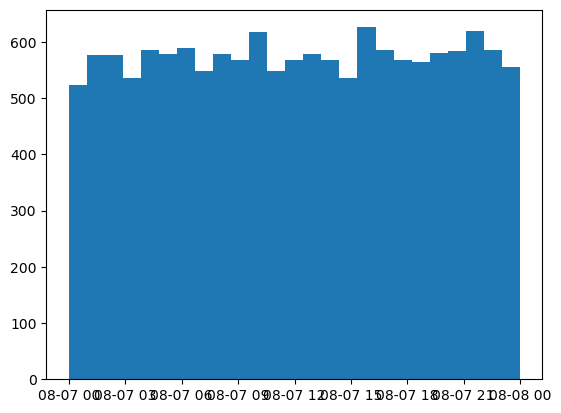

In [102]:
plt.hist(nasa_data.time, bins='auto')

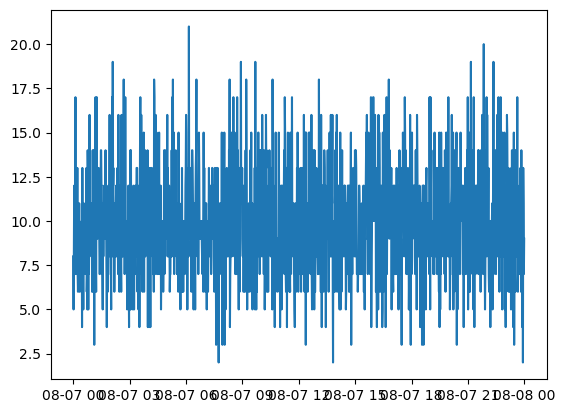

In [106]:
timed_object_count = nasa_data.groupby(by='time')['object'].count()
plt.plot(timed_object_count.index, timed_object_count, label='Object Count')

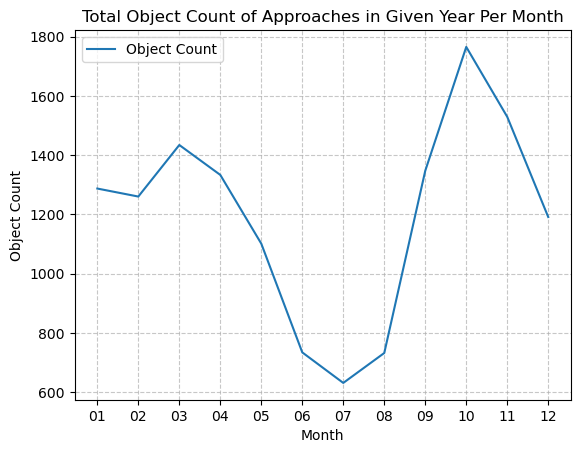

In [233]:
data_month = nasa_data['date'].dt.strftime('%m')
object_count_month = nasa_data.groupby(by=data_month)['object'].count()
plt.plot(object_count_month.index, object_count_month, label='Object Count')

plt.xlabel("Month")
plt.ylabel("Object Count")
plt.title("Total Object Count of Approaches in Given Year Per Month")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

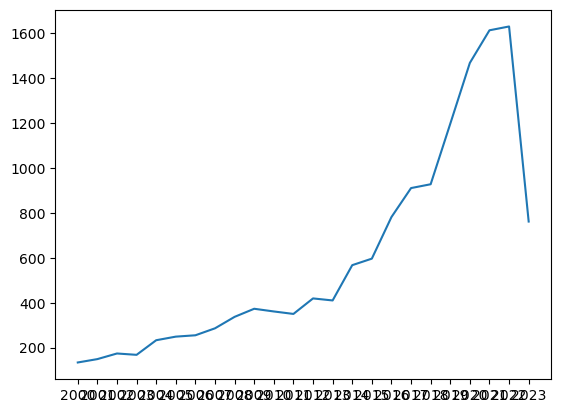

In [110]:
data_year = nasa_data['date'].dt.strftime('%Y')
object_count_year = nasa_data.groupby(by=data_year)['object'].count()
plt.plot(object_count_year.index, object_count_year, label='Object Count')

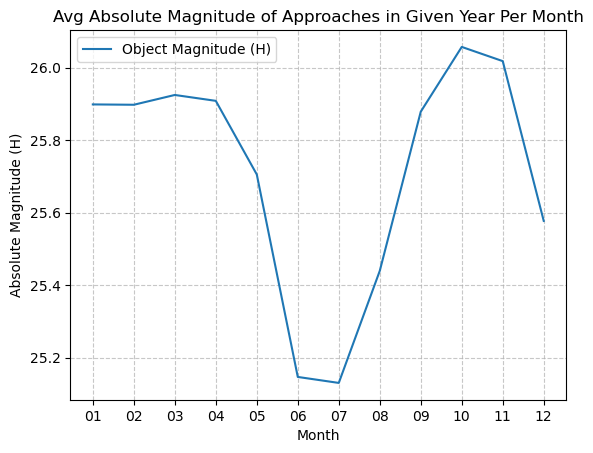

In [231]:
object_mag_month = nasa_data.groupby(by=data_month)['abs_magnitude_h'].mean()
plt.plot(object_mag_month.index, object_mag_month, label='Object Magnitude (H)')

plt.xlabel("Month")
plt.ylabel("Absolute Magnitude (H)")
plt.title("Avg Absolute Magnitude of Approaches in Given Year Per Month")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

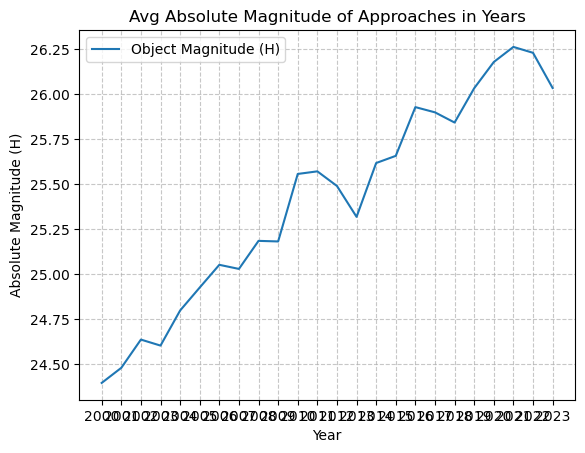

In [230]:
object_mag_year = nasa_data.groupby(by=data_year)['abs_magnitude_h'].mean()
plt.plot(object_mag_year.index, object_mag_year, label='Object Magnitude (H)')

plt.xlabel("Year")
plt.ylabel("Absolute Magnitude (H)")
plt.title("Avg Absolute Magnitude of Approaches in Years")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

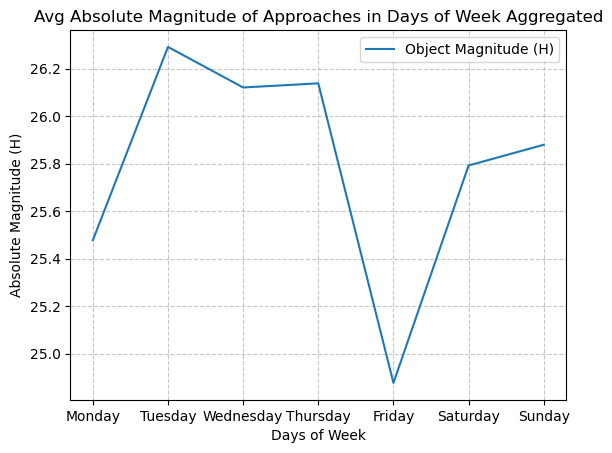

In [232]:
object_mag_week = nasa_data.groupby(by=days_of_week)['abs_magnitude_h'].mean()
plt.plot(object_mag_week.index, object_mag_week, label='Object Magnitude (H)')

plt.xlabel("Days of Week")
plt.ylabel("Absolute Magnitude (H)")
plt.title("Avg Absolute Magnitude of Approaches in Days of Week Aggregated")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

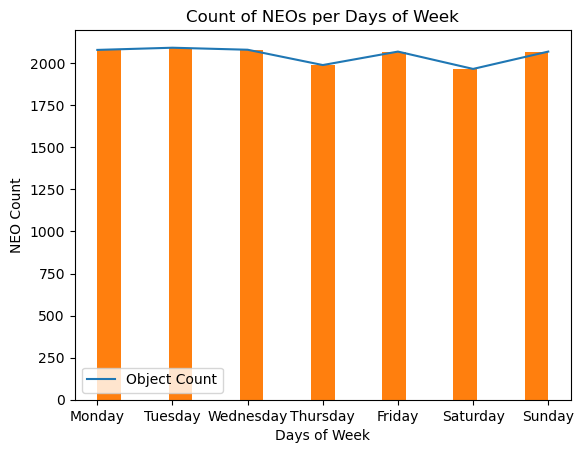

In [170]:
days_of_week = nasa_data['date'].dt.day_name().sort_values()
days_of_week = pd.Categorical(days_of_week, ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
object_count_week = nasa_data.groupby(by=days_of_week)['object'].count()
plt.plot(object_count_week.index, object_count_week, label='Object Count')
plt.hist(days_of_week, bins='auto')

plt.xlabel("Days of Week")
plt.ylabel("NEO Count")
plt.title("Count of NEOs per Days of Week")
plt.legend()
plt.show()

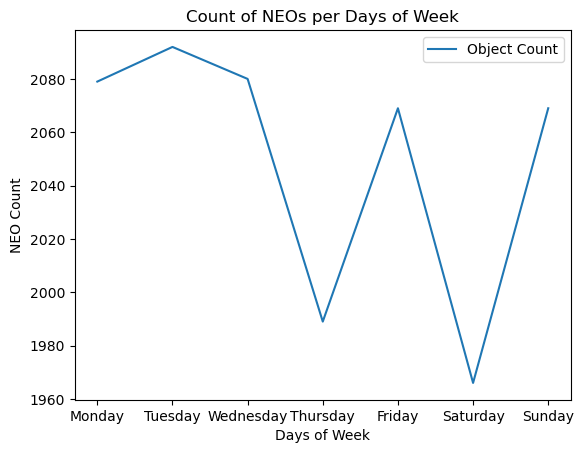

In [162]:
plt.plot(object_count_week.index, object_count_week, label='Object Count')

plt.xlabel("Days of Week")
plt.ylabel("NEO Count")
plt.title("Count of NEOs per Days of Week")
plt.legend()
plt.show()

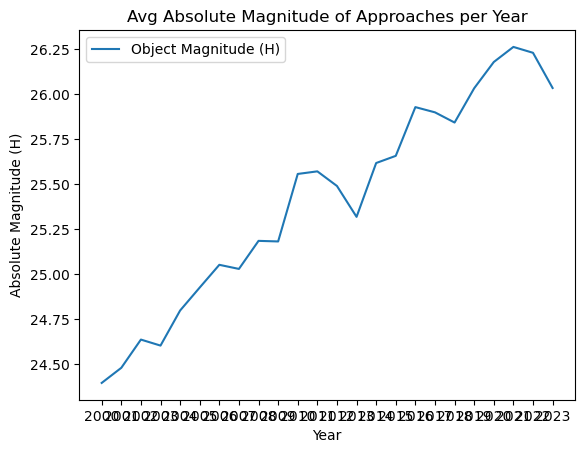

In [143]:
object_mag_year = nasa_data.groupby(by=data_year)['abs_magnitude_h'].mean()
plt.plot(object_mag_year.index, object_mag_year, label='Object Magnitude (H)')

plt.xlabel("Year")
plt.ylabel("Absolute Magnitude (H)")
plt.title("Avg Absolute Magnitude of Approaches per Year")
plt.legend()
plt.show()

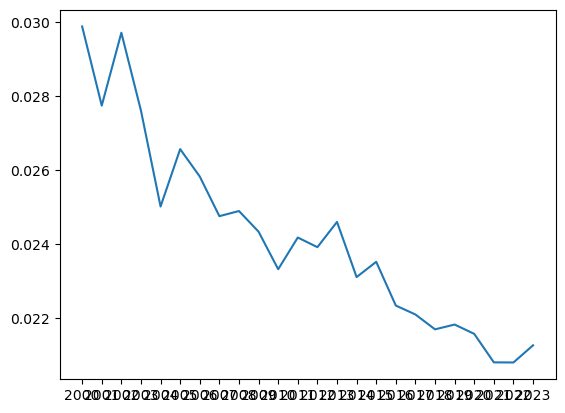

In [144]:
object_dist_year = nasa_data.groupby(by=data_year)['dist_avg_au'].mean()
plt.plot(object_dist_year.index, object_dist_year, label='Average Distance by AU per Year')

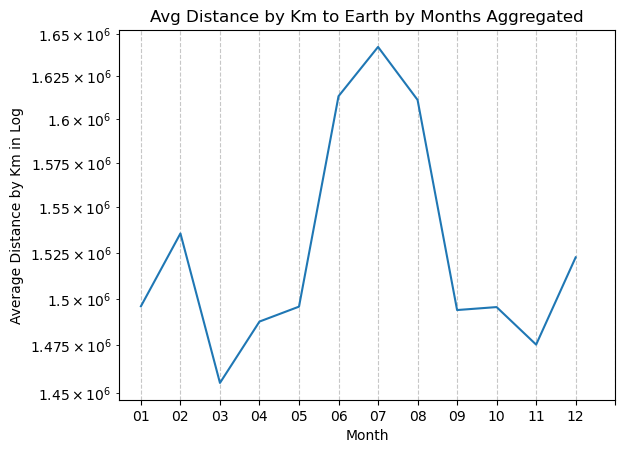

In [219]:
object_dist_month = nasa_data.groupby(by=data_month)['dist_avg_km'].mean()
plt.plot(object_dist_month.index, object_dist_month, label='Average Distance in Km by Months')

plt.xlabel("Month")
plt.ylabel("Average Distance by Km in Log")
plt.yscale('log')
plt.title("Avg Distance by Km to Earth by Months Aggregated")
plt.xticks(range(13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

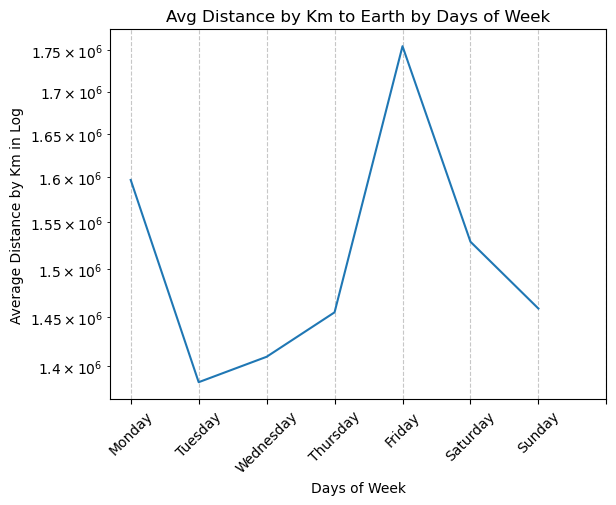

In [228]:
object_dist_week = nasa_data.groupby(by=days_of_week)['dist_avg_km'].mean()
plt.plot(object_dist_week.index, object_dist_week, label='Average Distance in Km by Days of Week')

plt.xlabel("Days of Week")
plt.ylabel("Average Distance by Km in Log")
plt.yscale('log')
plt.title("Avg Distance by Km to Earth by Days of Week")
plt.xticks(range(8), rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

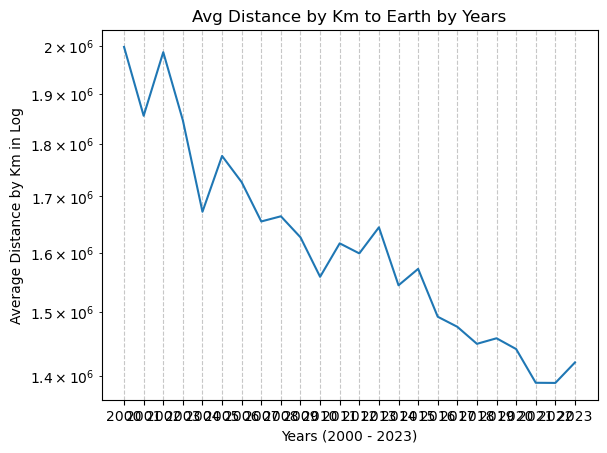

In [227]:
object_dist_year = nasa_data.groupby(by=data_year)['dist_avg_km'].mean()
plt.plot(object_dist_year.index, object_dist_year, label='Average Distance in Km by Years')

plt.xlabel("Years (2000 - 2023)")
plt.ylabel("Average Distance by Km in Log")
plt.yscale('log')
plt.title("Avg Distance by Km to Earth by Years")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [161]:
len(nasa_data.index)

14344

TypeError: unhashable type: 'numpy.ndarray'

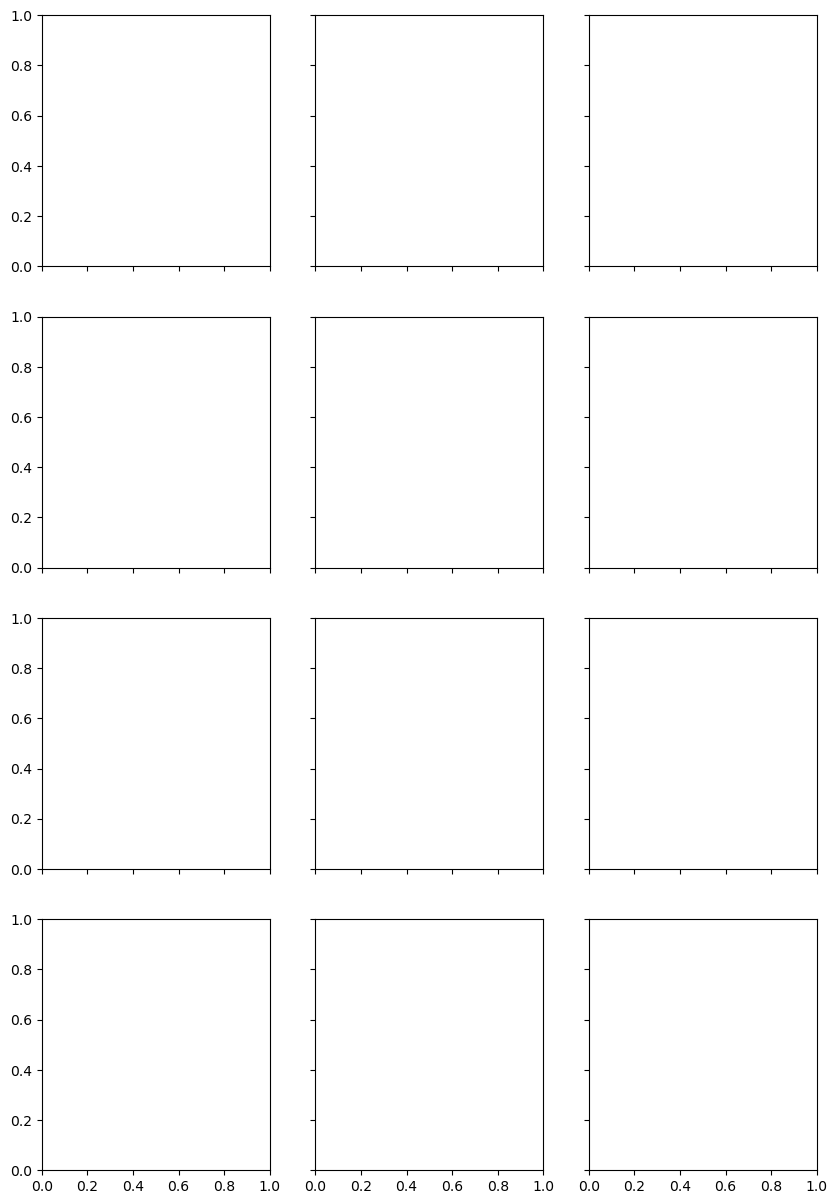

In [212]:
#datetime format
#nasa_date['date']
# get the month
#data_month


# month names
month_names = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']



#subplots
fig, axs = plt.subplots(4, 3, figsize=(10, 15), sharex=True, sharey=True)

#loop through each month by days of the week
for month, ax in zip(range(1, 13), axs.flat):
    ax.bar(object_count_week.index, object_count_week, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Day of the Week')
    ax.set_title('Count of NEO Approaches')
    ax.set_xticks(range(7))
    ax.grid(True, linestyle='--', alpha=0.7)

    #values on bars
    for i, v in enumerate(object_count_week):
        ax.text(i, v, str(v), ha='center', va='bottom')

    #y axis only on left plots 
    if data_month % 3 == 1:
        ax.set_ylabel('# of Sightings', rotation=45, ha='right')

plt.tight_layout()

plt.show()